### 1-1 Daum 뉴스기사 제목 스크래핑 하기

In [ ]:
import requests
import bs4
from bs4 import BeautifulSoup

url = 'https://news.daum.net/economy'
print(url)

req_header = {
    'referer':url,
    'user-agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.3'
}

res = requests.get(url, headers = req_header)
res.encoding = "UTF-8"

print(type(res))
print(res.status_code)

if not res.ok:
    exit()

soup = BeautifulSoup(res.text, 'html.parser')
extracted = soup.select("ul.list_newsheadline2 li a")
print(type(extracted), len(extracted))

for ex in extracted:
    link = ex['href']
    title = ex.select_one("div.cont_thumb strong.tit_txt").text.strip()
    print(link)
    print(title)

#### 1-2 Daum 뉴스기사 제목 스크래핑 하기 코드를 섹션별로 처리하는 함수로 구현하기

In [ ]:
import requests
import bs4
from bs4 import BeautifulSoup

section_dict = {'기후/환경':'climate','사회':'society','경제':'economy','정치':'politics',\
             '국제':'world','문화':'culture','생활':'life','IT/과학':'tech','인물':'people'}

basic_url = 'https://news.daum.net/'

def print_news(section_name):
    url = basic_url + section_dict[section_name]

    req_header = {
        'referer':url,
        'user-agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.3'
    }

    res = requests.get(url, headers = req_header)
    res.encoding = "UTF-8"

    if not res.ok:
        return

    print(f'======> {url} {section_name} 뉴스 <======')
    
    soup = BeautifulSoup(res.text, 'html.parser')
    extracted = soup.select("ul.list_newsheadline2 li a")

    for ex in extracted:
        link = ex['href']
        title = ex.select_one("div.cont_thumb strong.tit_txt").text.strip()
        print(link)
        print(title)
    

print_news('경제')
print_news('사회')


### 2-1 Nate 뉴스기사 제목 스크래핑하기

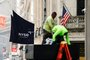

호르무즈 불확실성에 뉴욕증시 이틀째 하락…유가도 상승
https://news.nate.com/view/20260812n01573?mid=n0100


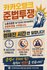

카카오뱅크 노조, 12일 0시부터 부분 파업…"근로시간 외 근무 거부"
https://news.nate.com/view/20260812n07520?mid=n0100


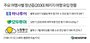

"계획은 NO, 취향은 YES"…2030이 다시 패키지 찾는 이유
https://news.nate.com/view/20260812n07519?mid=n0100


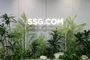

SSG닷컴, 7월 그로서리 매출 12%↑…배송·멤버십 강화
https://news.nate.com/view/20260812n07518?mid=n0100


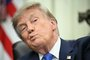

"韓 규제 당국, 우방을 적으로 돌려…트럼프가 방관하지 않을 것"
https://news.nate.com/view/20260812n01699?mid=n0100


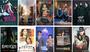

'벡델데이 2026' 시리즈 '벡델초이스 10' 공개…김고은 작품 3편 선정
https://news.nate.com/view/20260812n07516?mid=n0100


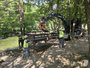

강릉시, 하천 불법점용 703건 적발…620건 정비 완료
https://news.nate.com/view/20260812n07515?mid=n0100


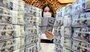

원·달러 환율 3원 내린 1412.9원
https://news.nate.com/view/20260812n07514?mid=n0100


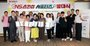

NS홈쇼핑, 5070 고객과 방송 콘텐츠 공동 제작
https://news.nate.com/view/20260812n07513?mid=n0100


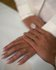

1조4000억원 슈퍼커플 탄생! '슈퍼스타' 호날두, 품절남 됐다…'10년 연인' 로드리게스와 다섯 자녀 축복 속 결혼
https://news.nate.com/view/20260812n07512?mid=n0100


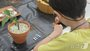

한국수목원정원관리원 광복절 맞아 국립수목원 3곳 무료 개방
https://news.nate.com/view/20260812n07511?mid=n0100


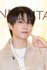

[현장포토] "디스 앤드 핸섬"…한, 콕 찍은 잘생김
https://news.nate.com/view/20260812n06376?mid=n0100


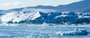

영국까지 단 20일, 중국 '아이스 실크로드' 열었다
https://news.nate.com/view/20260812n00233?mid=n0100


경동나비엔, 2분기 영업이익 842억원…전년 比 64.6% '껑충'
https://news.nate.com/view/20260812n07508?mid=n0100


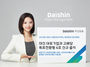

대신자산운용, 국내 대표기업·고배당주 투자 목표전환형 펀드 출시
https://news.nate.com/view/20260812n07507?mid=n0100


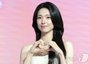

"내 증조부 안상호, 고종 독살 어의…XX 더럽다"…13년 전 글, 누가 썼지?
https://news.nate.com/view/20260812n07506?mid=n0100


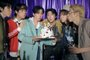

SF9, '터내서티' 두 번째 콘셉트 포토 공개…10주년 기념 파티
https://news.nate.com/view/20260812n07505?mid=n0100


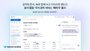

네이버클라우드, 공공 협업툴 '네이버웍스'에 AI 검색·문서 기능 추가
https://news.nate.com/view/20260812n07504?mid=n0100


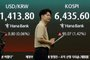

반도체 훈풍에 코스피 장초반 강세…코스닥은 반락
https://news.nate.com/view/20260812n07503?mid=n0100


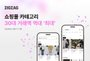

지그재그 "30대 후반은 오프라인 선호" 통념 깼다…거래액 36%↑
https://news.nate.com/view/20260812n07502?mid=n0100


In [1]:
import requests
import bs4
from bs4 import BeautifulSoup
from urllib.parse import urljoin
from IPython.display import Image, display

url = "https://news.nate.com/recent?mid=n0100"
req_header = {
    'referer':url,
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.3'
}

res = requests.get(url, headers = req_header)
if res.ok:
    soup = BeautifulSoup(res.text, 'html.parser')
    extracted = soup.select("a[href$='mid=n0100']") 

    for ex in extracted:
        if "recent" in ex['href']:
            continue;

        link = ex['href']
        title = ex.select_one("h2.tit").text.strip()
        src = ex.select_one("img")

        if src:
            display(Image(urljoin(url, src["src"])))

        print(title)
        print(urljoin(url, link))

        

### 2-2. 하나의 네이버 웹툰과 1개의 회차에 대한 Image 다운로드 하기

In [42]:
import requests
import bs4
from bs4 import BeautifulSoup
import os

def download_one_episode(title, no, url):

    req_header = {
        'referer':url,
        'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.3'
    }

    res = requests.get(url, headers = req_header)

    if not res.ok:
        print(res.status_code)
        return

    soup = BeautifulSoup(res.text, 'html.parser')
    img_list = soup.select("img[src*='IMAG01']")

    file_path = os.path.join("img", title, str(no))
    os.makedirs(file_path, exist_ok=True)

    for index, img in enumerate(img_list):
        image = img['src']
        image_res = requests.get(image, headers = req_header)

        if not image_res.ok:
            print(image_res.status_code)
            return

        image_name = f"image{index+1}.jpg"
        image_path = os.path.join(file_path, image_name)

        with open(image_path, 'wb') as file:
            file.write(image_res.content)

download_one_episode('일렉시드',341,'https://comic.naver.com/webtoon/detail?titleId=717481&no=341&week=wed')
